In [1]:
# ============================================================
# FUNCTION 3 — WEEK 5 CLEAN REBUILD
# ============================================================

import numpy as np

from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel
)

# ------------------------------------------------------------
# 1. Load the original Function 3 data
# ------------------------------------------------------------

X = np.load("function3/initial_inputs.npy")
Y = np.load("function3/initial_outputs.npy").reshape(-1)

# ------------------------------------------------------------
# 2. Add Weeks 1–4 exactly once
# ------------------------------------------------------------

week1_x = np.array([
    [0.433072, 0.324771, 0.537731]
])
week1_y = np.array([
    -0.022514823783463457
])

week2_x = np.array([
    [0.364352, 0.404312, 0.451822]
])
week2_y = np.array([
    -0.014995206499628672
])

week3_x = np.array([
    [0.987871, 0.206852, 0.790275]
])
week3_y = np.array([
    -0.09932090801789271
])

week4_x = np.array([
    [0.514352, 0.554312, 0.412747]
])
week4_y = np.array([
    -0.019738170400010385
])

X = np.vstack([
    X,
    week1_x,
    week2_x,
    week3_x,
    week4_x
])

Y = np.concatenate([
    Y,
    week1_y,
    week2_y,
    week3_y,
    week4_y
])

best_index = np.argmax(Y)
best_x = X[best_index]
best_y = Y[best_index]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("\nBest observed input:", best_x)
print("Best observed output:", best_y)

# ------------------------------------------------------------
# 3. Fit an ARD Gaussian Process
#
# Separate lengthscales allow the model to learn that some
# variables change more quickly than others.
# ------------------------------------------------------------

kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(
        length_scale=np.array([0.4, 0.4, 0.08]),
        length_scale_bounds=(0.005, 3.0),
        nu=2.5
    )
    + WhiteKernel(
        noise_level=1e-6,
        noise_level_bounds=(1e-10, 1e-2)
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=25,
    random_state=53
)

gp.fit(X, Y)

print("\nFitted kernel:")
print(gp.kernel_)

# Extract the fitted ARD lengthscales
lengthscales = np.asarray(
    gp.kernel_.k1.k2.length_scale
)

importance = 1 / lengthscales
importance = importance / importance.sum()

print("\nFitted lengthscales:", lengthscales)
print("Normalised input influence:")

for i, value in enumerate(importance, start=1):
    print(f"x{i}: {value:.4f}")

# ------------------------------------------------------------
# 4. Generate Week 5 candidates
#
# We search around the current best.
# x3 receives the smallest movement because it previously
# appeared to be the most sensitive variable.
# ------------------------------------------------------------

rng = np.random.default_rng(53)

very_local = rng.normal(
    loc=best_x,
    scale=[0.020, 0.020, 0.008],
    size=(20_000, 3)
)

local = rng.normal(
    loc=best_x,
    scale=[0.055, 0.055, 0.020],
    size=(20_000, 3)
)

wider_local = rng.normal(
    loc=best_x,
    scale=[0.120, 0.120, 0.040],
    size=(10_000, 3)
)

# Include interpolation between the two strongest recent regions
blend_weights = rng.uniform(0, 1, size=(10_000, 1))

blended_candidates = (
    blend_weights * week2_x
    + (1 - blend_weights) * week4_x
)

blended_candidates += rng.normal(
    loc=0,
    scale=[0.025, 0.025, 0.010],
    size=(10_000, 3)
)

# Retain a small amount of global exploration
global_candidates = rng.uniform(
    0,
    1,
    size=(5_000, 3)
)

candidates = np.vstack([
    very_local,
    local,
    wider_local,
    blended_candidates,
    global_candidates
])

candidates = np.clip(candidates, 0, 1)

# ------------------------------------------------------------
# 5. Remove candidates that are almost duplicates
# ------------------------------------------------------------

distances = np.linalg.norm(
    candidates[:, None, :] - X[None, :, :],
    axis=2
)

minimum_distance = distances.min(axis=1)

candidates = candidates[
    minimum_distance > 0.003
]

# ------------------------------------------------------------
# 6. Predict candidate performance
# ------------------------------------------------------------

mean, std = gp.predict(
    candidates,
    return_std=True
)

# Expected Improvement
xi = 0.001

improvement = mean - best_y - xi

with np.errstate(divide="ignore", invalid="ignore"):
    z = improvement / std

    expected_improvement = (
        improvement * norm.cdf(z)
        + std * norm.pdf(z)
    )

expected_improvement[std < 1e-12] = 0

# Moderate UCB
kappa = 0.65
ucb = mean + kappa * std

# ------------------------------------------------------------
# 7. Filter out candidates with weak predicted means
#
# This prevents uncertainty alone from pushing the search
# back into clearly poor regions.
# ------------------------------------------------------------

mean_filter = mean >= (best_y - 0.010)

if np.sum(mean_filter) < 100:
    mean_filter = mean >= (best_y - 0.020)

filtered_candidates = candidates[mean_filter]
filtered_mean = mean[mean_filter]
filtered_std = std[mean_filter]
filtered_ei = expected_improvement[mean_filter]
filtered_ucb = ucb[mean_filter]

# Normalise acquisition scores
ei_normalised = (
    filtered_ei - filtered_ei.min()
) / (
    filtered_ei.max()
    - filtered_ei.min()
    + 1e-12
)

ucb_normalised = (
    filtered_ucb - filtered_ucb.min()
) / (
    filtered_ucb.max()
    - filtered_ucb.min()
    + 1e-12
)

# Mostly exploit because we already have a promising region
acquisition = (
    0.75 * ei_normalised
    + 0.25 * ucb_normalised
)

best_candidate_index = np.argmax(acquisition)
week5_query = filtered_candidates[best_candidate_index]

# ------------------------------------------------------------
# 8. Print the proposed Week 5 query
# ------------------------------------------------------------

print("\nMethod:")
print("Filtered local Expected Improvement with moderate UCB")

print("\nCandidates passing mean filter:",
      len(filtered_candidates))

print("\nSuggested Week 5 query:")
print(week5_query)

print("\nPortal format:")
print("-".join(
    f"{value:.6f}"
    for value in week5_query
))

print("\nPredicted mean:",
      filtered_mean[best_candidate_index])

print("Predicted standard deviation:",
      filtered_std[best_candidate_index])

print("Expected Improvement:",
      filtered_ei[best_candidate_index])

print("UCB:",
      filtered_ucb[best_candidate_index])

print("Distance from current best:",
      np.linalg.norm(
          week5_query - best_x
      ))

print("Distance from Week 4 point:",
      np.linalg.norm(
          week5_query - week4_x[0]
      ))

X shape: (19, 3)
Y shape: (19,)

Best observed input: [0.364352 0.404312 0.451822]
Best observed output: -0.014995206499628672

Fitted kernel:
1.39**2 * Matern(length_scale=[3, 3, 0.0935], nu=2.5) + WhiteKernel(noise_level=0.01)

Fitted lengthscales: [3.         3.         0.09347001]
Normalised input influence:
x1: 0.0293
x2: 0.0293
x3: 0.9413

Method:
Filtered local Expected Improvement with moderate UCB

Candidates passing mean filter: 49389

Suggested Week 5 query:
[0.92636475 0.99704516 0.45630455]

Portal format:
0.926365-0.997045-0.456305

Predicted mean: 0.015267245737622392
Predicted standard deviation: 0.03410517200434465
Expected Improvement: 0.03295938703707292
UCB: 0.03743560754044642
Distance from current best: 0.8168298578506695
Distance from Week 4 point: 0.6063533723513255


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


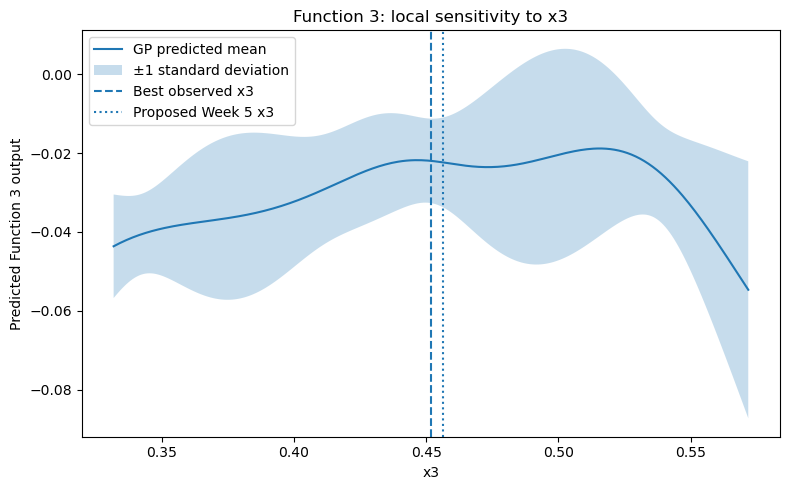

In [2]:
# ------------------------------------------------------------
# 9. Plot sensitivity along x3
# ------------------------------------------------------------

import matplotlib.pyplot as plt

x3_values = np.linspace(
    max(0, best_x[2] - 0.12),
    min(1, best_x[2] + 0.12),
    300
)

slice_points = np.column_stack([
    np.full_like(x3_values, best_x[0]),
    np.full_like(x3_values, best_x[1]),
    x3_values
])

slice_mean, slice_std = gp.predict(
    slice_points,
    return_std=True
)

plt.figure(figsize=(8, 5))

plt.plot(
    x3_values,
    slice_mean,
    label="GP predicted mean"
)

plt.fill_between(
    x3_values,
    slice_mean - slice_std,
    slice_mean + slice_std,
    alpha=0.25,
    label="±1 standard deviation"
)

plt.axvline(
    best_x[2],
    linestyle="--",
    label="Best observed x3"
)

plt.axvline(
    week5_query[2],
    linestyle=":",
    label="Proposed Week 5 x3"
)

plt.xlabel("x3")
plt.ylabel("Predicted Function 3 output")
plt.title("Function 3: local sensitivity to x3")
plt.legend()
plt.tight_layout()
plt.show()